# Chapter 26: Fourth (Holonomy) Proof of the Global Gauss-Bonnet Theorem

## Source Span And Chapter Goal

This notebook covers printed pages 257-260 and PDF pages 286-289 of *Visual Differential Geometry and Forms*. The source span was extracted with `pdftotext` for orientation only. The prose, code, diagrams, and checks below are original teaching material; no textbook prose, screenshots, page crops, or figure layouts are copied.

**Chapter question.** How can holonomy, which first looks like a loop-only measurement, prove the global Gauss-Bonnet theorem intrinsically?

The proof route is short but easy to blur:

1. Extend holonomy temporarily to an open curve by measuring against a nonsingular fiducial field `U`.
2. Replace the arbitrary `U` comparison by a comparison against a vector field `F` whose singularities carry index.
3. Apply the polygon identity to every cell in a surface partition.
4. Cancel every shared oriented edge with its opposite traversal.
5. Read the surviving equality as total curvature equals `2*pi` times total index, then use Poincare-Hopf to get `2*pi*chi`.

## Computational Translation Guide

| Book object | Computational object in this notebook | What to inspect |
| --- | --- | --- |
| Parallel transport along an open edge | A smoothly varying transported angle `w_parallel(t)` | Only angle *changes* are meaningful, and they require a comparator field. |
| Fiducial vector field `U` | Two different nonsingular angle functions along the same edge | `R_U(K)` changes when `U` changes, so it is a proof device rather than an invariant. |
| Vector field `F` with isolated singularities | Index ledger whose sum is compared with curvature mass | The arbitrary `U` has disappeared; the singularities remain. |
| Polygon partition | Oriented edge-pair bookkeeping | A shared edge contributes `Phi(K)` from one polygon and `Phi(-K)` from the neighbor. |
| Closed surface | Triangulated mesh with every edge incident to two faces | There is no exterior boundary term left after summing all polygons. |
| Global theorem | Balance table: curvature, turning/index, topology | The residual `total_curvature - 2*pi*sum(index)` must vanish. |


## Orientation And Notation

The chapter uses the same letter-like symbols for several related measurements, so the first job is to keep their roles separate. Closed holonomy is a loop invariant: transport a tangent vector all the way around a closed boundary and compare the returned vector with the initial one. Open-edge holonomy is not an invariant by itself, because the starting and ending tangent planes are different comparison sites. The auxiliary field `U` gives a temporary ruler along the edge, but changing that ruler changes the number.

The proof succeeds because the arbitrary ruler is eliminated before the global statement is made. Once a vector field `F` is introduced, the comparison angle from `F` to the transported vector has a signed endpoint change along each edge. Singularities of `F` appear through index, not through a visual defect in the edge itself. The useful mental model is a ledger: each polygon contributes a curvature amount, an index amount if it encloses a singularity, and a signed list of boundary-edge changes. The global theorem is what remains after all interior ledger entries have been paired with their negatives.


In [1]:
from __future__ import annotations

import json
import math
import sys
from collections import Counter
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon
import networkx as nx
import numpy as np
import pandas as pd
from PIL import Image
import trimesh
from IPython.display import Markdown, display

BOOK_ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the VDGF book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, save_json, save_matplotlib

ARTIFACT_TOPIC = "chapter-26"
ARTIFACT_BASE = BOOK_ROOT / "artifacts"
FIGURE_SLUG = "figures"
CHECK_SLUG = "checks"

np.set_printoptions(precision=5, suppress=True)
visual_records: list[dict[str, object]] = []

PALETTE = {
    "ink": "#1f2933",
    "blue": "#2f6fbb",
    "teal": "#2a9d8f",
    "red": "#c44e52",
    "gold": "#d59f0f",
    "violet": "#7b5ea7",
    "gray": "#6b7280",
    "paper": "#fbfcfe",
}


def rel(path: Path) -> str:
    return path.relative_to(BOOK_ROOT).as_posix()


def image_stats(path: Path) -> dict[str, float | int]:
    image = Image.open(path).convert("RGB")
    array = np.asarray(image, dtype=float)
    return {
        "width": int(image.width),
        "height": int(image.height),
        "pixel_std": float(array.std()),
        "file_size": int(path.stat().st_size),
    }


def save_and_register(fig, filename: str, concept: str, checks: dict[str, object], *, width: int = 760) -> Path:
    path = save_matplotlib(fig, ARTIFACT_TOPIC, FIGURE_SLUG, filename, dpi=170, root=ARTIFACT_BASE)
    plt.close(fig)
    stats = image_stats(path)
    record = {
        "filename": filename,
        "concept": concept,
        "relative_path": rel(path),
        "metrics": stats,
        "checks": checks,
    }
    visual_records.append(record)
    assert stats["file_size"] > 1000, f"artifact too small: {filename}"
    assert stats["pixel_std"] > 1.0, f"artifact looks blank: {filename}"
    display_artifact(path, width=width)
    return path


def arrow(ax, start, end, *, color, lw=2.0, style="-|>", mutation_scale=13):
    patch = FancyArrowPatch(start, end, arrowstyle=style, mutation_scale=mutation_scale, color=color, linewidth=lw)
    ax.add_patch(patch)
    return patch


print(f"Book root: {BOOK_ROOT.name}")
print(f"Artifact subtree: {rel(ARTIFACT_BASE / ARTIFACT_TOPIC)}")


Book root: Visual-Differential-Geometry-and-Forms
Artifact subtree: artifacts/chapter-26


In [2]:
source_span = {
    "label": "Chapter 26",
    "title": "Fourth (Holonomy) Proof of the Global Gauss-Bonnet Theorem",
    "printed_pages": "257-260",
    "pdf_pages": "286-289",
    "source_pdf": "Visual-Differential-Geometry-and-Forms/Visual Differential Geometry and Forms.pdf",
    "source_words_read_by_pdftotext": 1589,
    "read_for_orientation_only": True,
    "focus": "Hopf's intrinsic holonomy proof of global Gauss-Bonnet, including open-curve holonomy, vector-field index, and oriented edge cancellation.",
}

storyboard = {
    "chapter_goal": "Make Hopf's holonomy proof inspectable as endpoint comparison, edge cancellation, mesh bookkeeping, and topology balance.",
    "source_span_read": {
        "printed_pages": source_span["printed_pages"],
        "pdf_pages": source_span["pdf_pages"],
        "source_pdf": source_span["source_pdf"],
        "source_map_note": "VDGF map gives pdf_page = printed_page + 29.",
    },
    "concept_inventory": [
        "Closed-loop holonomy is invariant, but an open-edge rotation needs a comparator field.",
        "The fiducial field U is allowed to be arbitrary because it will cancel from the proof.",
        "Comparing the transported vector with F leaves the index contribution of singularities.",
        "For every polygon, curvature mass minus 2*pi times enclosed index equals a sum of edge Phi terms.",
        "Every interior edge appears twice with opposite orientation, so Phi(K) + Phi(-K) = 0.",
        "A closed triangulated surface has no remaining exterior boundary; topology enters through the index sum.",
    ],
    "library_routing_table": [
        {
            "concept": "Open-curve endpoint comparison",
            "representation": "2D curve with angle traces",
            "library": "Matplotlib + NumPy",
            "why": "Static angle traces make dependence on the comparator field visible and easy to audit numerically.",
            "fallback": "Text angle ledger if plotting is unavailable.",
        },
        {
            "concept": "Boundary cancellation",
            "representation": "oriented adjacent polygons",
            "library": "Matplotlib",
            "why": "The proof move is a signed planar incidence diagram rather than a 3D rendering problem.",
            "fallback": "Signed edge table.",
        },
        {
            "concept": "Triangulated closed surface ledger",
            "representation": "small closed meshes plus V/E/F table",
            "library": "Trimesh for mesh combinatorics, Matplotlib for the durable artifact",
            "why": "Trimesh exposes the edge-incidence condition that makes cancellation global.",
            "fallback": "Pure combinatorial V/E/F table.",
        },
        {
            "concept": "Curvature, turning, topology balance",
            "representation": "residual ledger across genera",
            "library": "NumPy + Matplotlib",
            "why": "The theorem is an equality of totals; a residual plot catches sign and index mistakes.",
            "fallback": "JSON balance table.",
        },
        {
            "concept": "Proof dependency graph",
            "representation": "directed acyclic graph",
            "library": "NetworkX + Matplotlib",
            "why": "A proof-heavy chapter benefits from explicit dependency structure and reachability checks.",
            "fallback": "Ordered proof checklist.",
        },
    ],
    "visual_sequence": [
        {
            "filename": "open-curve-endpoint-comparison.png",
            "concept": "Open-curve endpoint comparison",
            "inspection_target": "Compare R_U(K) for two fiducial fields and see that only the closed proof sum is invariant.",
            "validation": "Changing the initial transported vector by a constant angle leaves the open-edge delta unchanged.",
        },
        {
            "filename": "boundary-cancellation-oriented-edges.png",
            "concept": "Boundary cancellation by opposite orientation",
            "inspection_target": "Inspect the same shared edge with opposite arrows in neighboring polygons.",
            "validation": "Phi(K) + Phi(-K) is numerically zero.",
        },
        {
            "filename": "triangulated-surface-ledger.png",
            "concept": "Triangulated closed surface ledger",
            "inspection_target": "Check that each mesh edge is incident to exactly two faces and that chi is computed from V-E+F.",
            "validation": "Sphere chi=2, torus chi=0, all displayed closed-mesh edges have incidence two.",
        },
        {
            "filename": "curvature-turning-topology-balance.png",
            "concept": "Curvature, index, and topology balance",
            "inspection_target": "Track total curvature and 2*pi times total index for several closed orientable genera.",
            "validation": "The residual total_curvature - 2*pi*sum(index) vanishes in every row.",
        },
        {
            "filename": "holonomy-proof-dependency-graph.png",
            "concept": "Holonomy proof dependency graph",
            "inspection_target": "Follow which local definitions are needed before the global theorem appears.",
            "validation": "The graph is acyclic and has a path from open-edge comparison to global Gauss-Bonnet.",
        },
    ],
    "artifact_plan": [
        "artifacts/chapter-26/figures/open-curve-endpoint-comparison.png",
        "artifacts/chapter-26/figures/boundary-cancellation-oriented-edges.png",
        "artifacts/chapter-26/figures/triangulated-surface-ledger.png",
        "artifacts/chapter-26/figures/curvature-turning-topology-balance.png",
        "artifacts/chapter-26/figures/holonomy-proof-dependency-graph.png",
        "artifacts/chapter-26/checks/source-span.json",
        "artifacts/chapter-26/checks/visual-storyboard.json",
        "artifacts/chapter-26/checks/balance-exploration.json",
        "artifacts/chapter-26/checks/boundary-cancellation-gauss-bonnet.json",
        "artifacts/chapter-26/checks/final-sanity.json",
    ],
    "computational_checks": [
        "Open-edge R_U changes with U, but not with a constant change of transported initial vector.",
        "Oppositely oriented edge Phi terms cancel.",
        "Closed triangulated meshes have edge incidence two and expected Euler characteristic.",
        "Curvature-index-topology residuals are zero to floating tolerance.",
        "Proof dependency graph is a DAG with the intended theorem path.",
        "All concept-named artifacts exist, are nonzero, and are visually nonblank by pixel statistics.",
    ],
    "proof_visualization_strategy": "Use endpoint comparison, oriented-edge cancellation, mesh ledger, balance plot, and NetworkX DAG.",
    "implementation_notes": {
        "artifact_topic": ARTIFACT_TOPIC,
        "write_boundary": "Only the assigned chapter notebook and artifacts/chapter-26 are written.",
        "copyright_boundary": "No source text, screenshots, page crops, or textbook figures are stored.",
    },
}

source_path = save_json(source_span, ARTIFACT_TOPIC, CHECK_SLUG, "source-span.json", root=ARTIFACT_BASE)
storyboard_path = save_json(storyboard, ARTIFACT_TOPIC, CHECK_SLUG, "visual-storyboard.json", root=ARTIFACT_BASE)

display(Markdown(f"Saved storyboard to `{rel(storyboard_path)}` and source map to `{rel(source_path)}`."))


Saved storyboard to `artifacts/chapter-26/checks/visual-storyboard.json` and source map to `artifacts/chapter-26/checks/source-span.json`.

## The Local Identity That Drives The Proof

For a polygon `P` whose boundary is split into oriented edges `K_j`, the chapter's proof turns holonomy into a signed edge ledger:

\[
\operatorname{curv}(P) - 2\pi I_F(P) = \sum_j \Phi(K_j),
\]

where `I_F(P)` is the index of the singularity of `F` inside `P` if one is present, and `Phi(K_j)` is the net change in the angle from `F` to the parallel-transported vector along that edge.

Two warnings carry most of the proof:

- `R_U(K)` for an open curve `K` depends on the arbitrary fiducial field `U`; it is scaffolding, not a final invariant.
- `Phi(-K) = -Phi(K)`, so when all polygons in a closed partition are summed, every interior edge cancels.


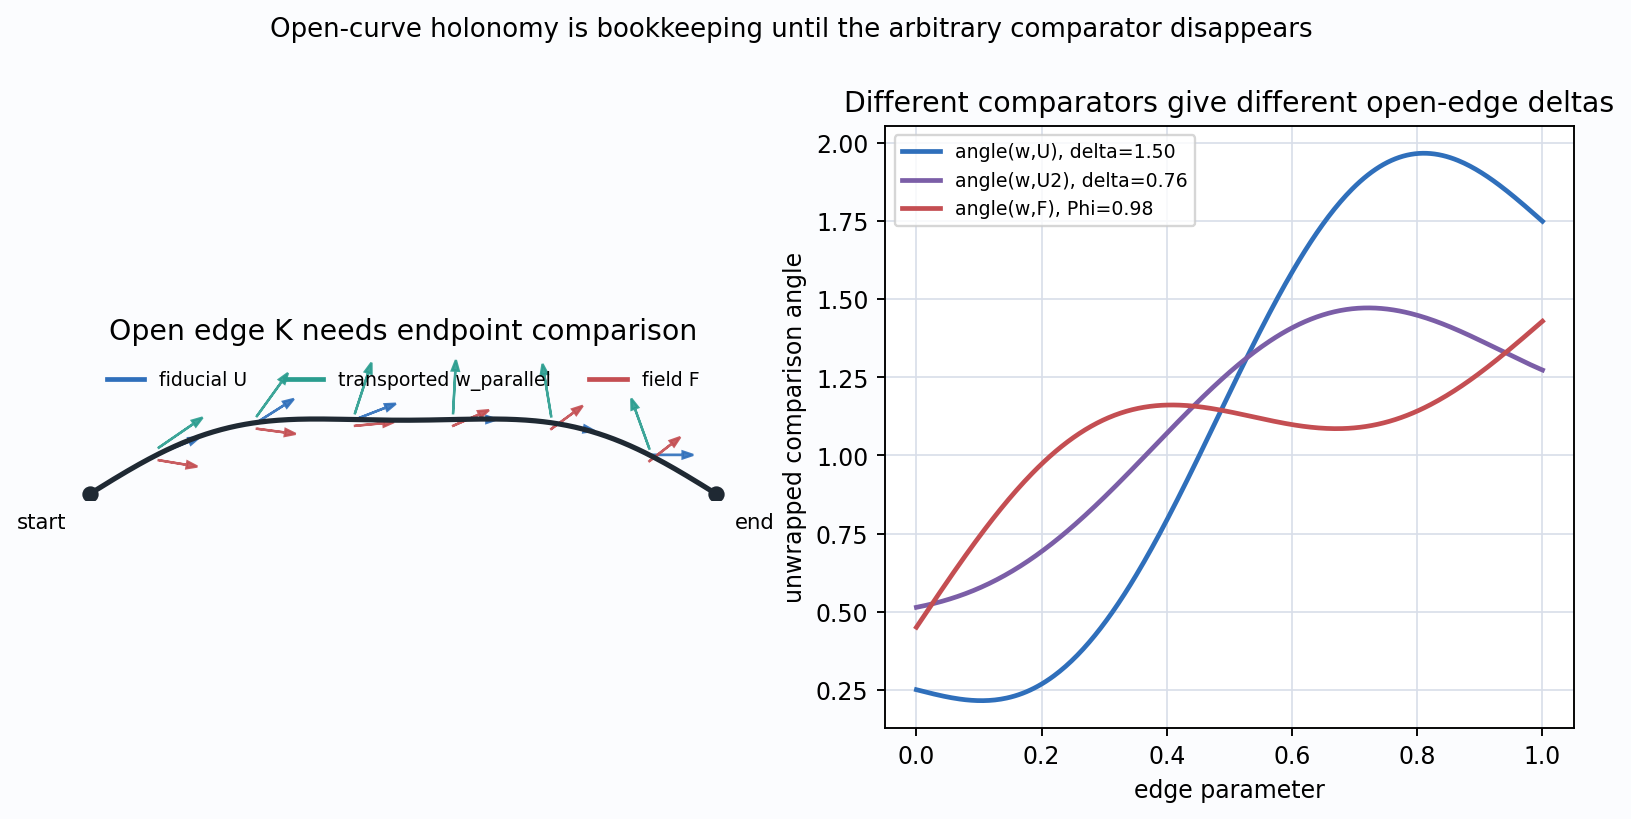

{
  "R_U": 1.5,
  "R_U_alternate_U": 0.7599999999999998,
  "Phi_relative_to_F": 0.9799999999999998,
  "R_U_depends_on_U": true,
  "constant_initial_vector_shift_invariant": true
}


In [3]:
t = np.linspace(0.0, 1.0, 320)
x = 4.0 * t
y = 0.55 * np.sin(np.pi * t) + 0.08 * np.sin(3 * np.pi * t)

U_angle = 0.10 + 0.42 * np.sin(2 * np.pi * t) + 0.18 * t
U_alt_angle = -0.25 + 0.18 * np.sin(2 * np.pi * t + 0.5) + 0.92 * t
w_angle = 0.35 + 1.68 * t + 0.20 * np.sin(np.pi * t)
F_angle = -0.10 + 0.70 * t - 0.22 * np.sin(2 * np.pi * t)


def angle_delta(values: np.ndarray) -> float:
    unwrapped = np.unwrap(values)
    return float(unwrapped[-1] - unwrapped[0])


RU = angle_delta(w_angle - U_angle)
RU_alt = angle_delta(w_angle - U_alt_angle)
Phi = angle_delta(w_angle - F_angle)
RU_shifted_initial_vector = angle_delta((w_angle + 0.9) - U_angle)

open_curve_checks = {
    "R_U": RU,
    "R_U_alternate_U": RU_alt,
    "Phi_relative_to_F": Phi,
    "R_U_depends_on_U": bool(abs(RU - RU_alt) > 0.2),
    "constant_initial_vector_shift_invariant": bool(abs(RU_shifted_initial_vector - RU) < 1e-12),
}

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.6), facecolor=PALETTE["paper"])
ax0.plot(x, y, color=PALETTE["ink"], lw=2.2)
ax0.scatter([x[0], x[-1]], [y[0], y[-1]], color=PALETTE["ink"], s=35, zorder=3)
ax0.text(x[0] - 0.15, y[0] - 0.22, "start", ha="right", fontsize=9)
ax0.text(x[-1] + 0.12, y[-1] - 0.22, "end", ha="left", fontsize=9)

samples = np.linspace(35, 285, 6, dtype=int)
for idx in samples:
    base = np.array([x[idx], y[idx]])
    for angle, color, scale, dy in [
        (U_angle[idx], PALETTE["blue"], 0.28, 0.00),
        (w_angle[idx], PALETTE["teal"], 0.34, 0.04),
        (F_angle[idx], PALETTE["red"], 0.25, -0.04),
    ]:
        vec = scale * np.array([np.cos(angle), np.sin(angle)])
        ax0.arrow(base[0], base[1] + dy, vec[0], vec[1], head_width=0.045, length_includes_head=True, color=color, alpha=0.9)

ax0.plot([], [], color=PALETTE["blue"], lw=2, label="fiducial U")
ax0.plot([], [], color=PALETTE["teal"], lw=2, label="transported w_parallel")
ax0.plot([], [], color=PALETTE["red"], lw=2, label="field F")
ax0.set_title("Open edge K needs endpoint comparison")
ax0.set_aspect("equal", adjustable="box")
ax0.axis("off")
ax0.legend(loc="upper center", ncols=3, frameon=False, fontsize=8)

ax1.plot(t, np.unwrap(w_angle - U_angle), color=PALETTE["blue"], lw=2, label=f"angle(w,U), delta={RU:.2f}")
ax1.plot(t, np.unwrap(w_angle - U_alt_angle), color=PALETTE["violet"], lw=2, label=f"angle(w,U2), delta={RU_alt:.2f}")
ax1.plot(t, np.unwrap(w_angle - F_angle), color=PALETTE["red"], lw=2, label=f"angle(w,F), Phi={Phi:.2f}")
ax1.set_xlabel("edge parameter")
ax1.set_ylabel("unwrapped comparison angle")
ax1.set_title("Different comparators give different open-edge deltas")
ax1.grid(True, color="#d8dee9", lw=0.7)
ax1.legend(fontsize=8, loc="upper left")

fig.suptitle("Open-curve holonomy is bookkeeping until the arbitrary comparator disappears", fontsize=11, y=1.02)
path_open = save_and_register(fig, "open-curve-endpoint-comparison.png", "Open-curve endpoint comparison", open_curve_checks)
assert open_curve_checks["R_U_depends_on_U"]
assert open_curve_checks["constant_initial_vector_shift_invariant"]
print(json.dumps(open_curve_checks, indent=2))


## What The Endpoint Diagram Is Testing

The open-curve diagram is deliberately not a model of a particular surface. It is a local tangent-plane bookkeeping model. The curve parameter stands for travel along an edge, and the angle traces stand for comparisons made along that edge. The two `U` traces are both nonsingular choices, so both are allowed as fiducial fields. Their different endpoint deltas show why `R_U(K)` cannot be the final geometric object.

The numerical check beside the figure tests a smaller invariant that must still hold: if the transported vector is replaced by another transported vector making a fixed initial angle with it, the measured change relative to the same comparator is unchanged. That is the computational echo of angle preservation under parallel transport. The proof uses this reliable part while discarding the arbitrary part introduced by `U`.


The figure above separates two facts that are often conflated. Along a single open edge, the number `R_U(K)` changes if the auxiliary field `U` is changed. But shifting the transported initial vector by a constant angle does not change the net delta, because parallel transport preserves angles between transported vectors. Hopf's proof uses the temporary `U` comparison only long enough to rewrite the expression in terms of `F` and its index.


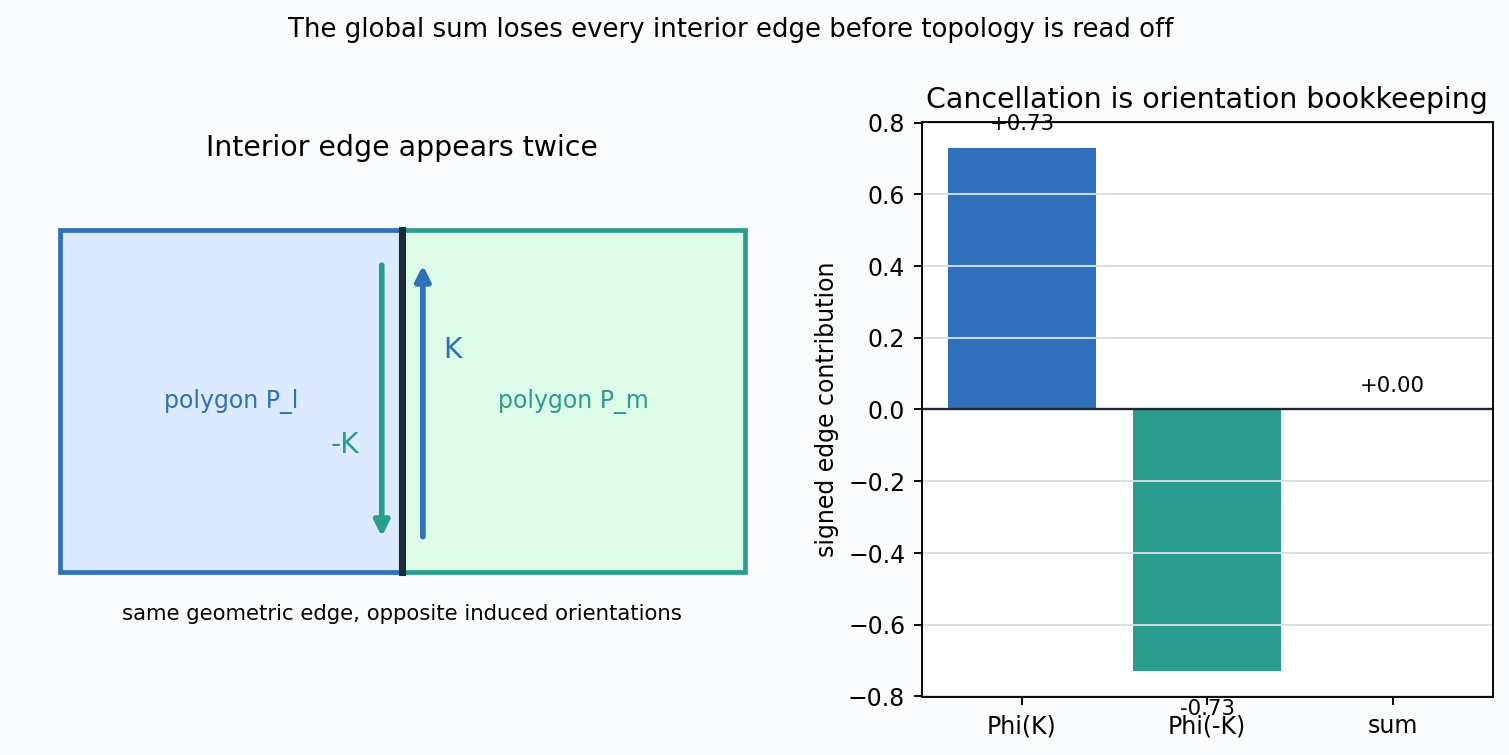

{
  "Phi_K": 0.73,
  "Phi_minus_K": -0.73,
  "pair_sum": 0.0,
  "oriented_pair_cancels": true
}


In [4]:
phi = 0.73
boundary_checks = {
    "Phi_K": phi,
    "Phi_minus_K": -phi,
    "pair_sum": phi + (-phi),
    "oriented_pair_cancels": bool(abs(phi + (-phi)) < 1e-12),
}

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.2, 4.4), facecolor=PALETTE["paper"], gridspec_kw={"width_ratios": [1.35, 1.0]})
left_poly = np.array([[-2, -1], [0, -1], [0, 1], [-2, 1]])
right_poly = np.array([[0, -1], [2, -1], [2, 1], [0, 1]])
ax0.add_patch(Polygon(left_poly, closed=True, facecolor="#dbeafe", edgecolor=PALETTE["blue"], lw=2))
ax0.add_patch(Polygon(right_poly, closed=True, facecolor="#dcfce7", edgecolor=PALETTE["teal"], lw=2))
ax0.plot([0, 0], [-1, 1], color=PALETTE["ink"], lw=3)

arrow(ax0, (0.12, -0.82), (0.12, 0.82), color=PALETTE["blue"], lw=2.4)
arrow(ax0, (-0.12, 0.82), (-0.12, -0.82), color=PALETTE["teal"], lw=2.4)
ax0.text(-1.0, 0.0, "polygon P_l", ha="center", va="center", fontsize=10, color=PALETTE["blue"])
ax0.text(1.0, 0.0, "polygon P_m", ha="center", va="center", fontsize=10, color=PALETTE["teal"])
ax0.text(0.24, 0.25, "K", color=PALETTE["blue"], fontsize=12)
ax0.text(-0.42, -0.30, "-K", color=PALETTE["teal"], fontsize=12)
ax0.text(0, -1.28, "same geometric edge, opposite induced orientations", ha="center", fontsize=9)
ax0.set_title("Interior edge appears twice")
ax0.set_aspect("equal", adjustable="box")
ax0.set_xlim(-2.25, 2.25)
ax0.set_ylim(-1.45, 1.35)
ax0.axis("off")

ax1.axhline(0, color=PALETTE["ink"], lw=1)
ax1.bar([0, 1, 2], [phi, -phi, 0.0], color=[PALETTE["blue"], PALETTE["teal"], PALETTE["gray"]])
ax1.set_xticks([0, 1, 2], ["Phi(K)", "Phi(-K)", "sum"])
ax1.set_ylabel("signed edge contribution")
ax1.set_title("Cancellation is orientation bookkeeping")
ax1.grid(True, axis="y", color="#d8dee9")
for xloc, value in zip([0, 1, 2], [phi, -phi, 0.0]):
    ax1.text(xloc, value + (0.05 if value >= 0 else -0.12), f"{value:+.2f}", ha="center", fontsize=9)

fig.suptitle("The global sum loses every interior edge before topology is read off", fontsize=11, y=1.02)
path_boundary = save_and_register(fig, "boundary-cancellation-oriented-edges.png", "Boundary cancellation by opposite orientation", boundary_checks)
assert boundary_checks["oriented_pair_cancels"]
print(json.dumps(boundary_checks, indent=2))


The cancellation is not a limit process and it does not require geodesic edges. It is a signed incidence fact: the same edge is part of two polygon boundaries, and the neighboring boundary traverses it in the reverse direction. This is why the local identity can be summed over an arbitrary polygonal partition.


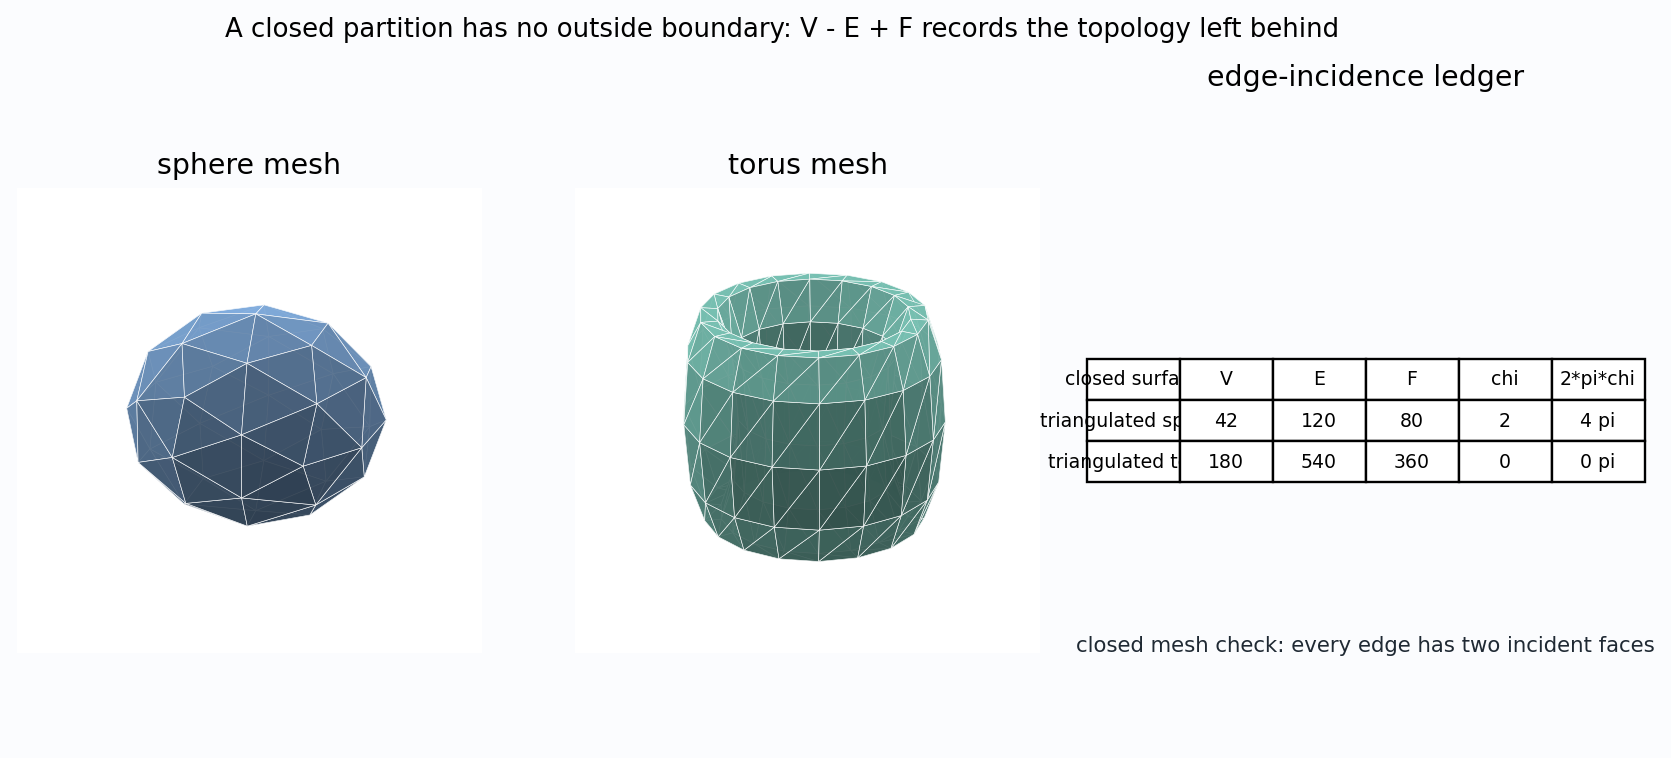

,surface,genus,vertices,edges,faces,chi_from_mesh,expected_chi,all_edges_incident_to_two_faces,total_curvature_by_gauss_bonnet
0,triangulated sphere,0,42,120,80,2,2,True,12.566371
1,triangulated torus,1,180,540,360,0,0,True,0.000000


In [5]:
def make_torus(n_major: int = 18, n_minor: int = 10, R: float = 1.7, r: float = 0.45) -> trimesh.Trimesh:
    vertices = []
    for i in range(n_major):
        u = 2 * math.pi * i / n_major
        for j in range(n_minor):
            v = 2 * math.pi * j / n_minor
            vertices.append([(R + r * math.cos(v)) * math.cos(u), (R + r * math.cos(v)) * math.sin(u), r * math.sin(v)])

    def idx(i: int, j: int) -> int:
        return (i % n_major) * n_minor + (j % n_minor)

    faces = []
    for i in range(n_major):
        for j in range(n_minor):
            a, b, c, d = idx(i, j), idx(i + 1, j), idx(i + 1, j + 1), idx(i, j + 1)
            faces.append([a, b, c])
            faces.append([a, c, d])
    return trimesh.Trimesh(vertices=np.asarray(vertices), faces=np.asarray(faces), process=False)


def mesh_ledger(mesh: trimesh.Trimesh, name: str, genus: int) -> dict[str, object]:
    counts: Counter[tuple[int, int]] = Counter()
    for face in np.asarray(mesh.faces, dtype=int):
        for a, b in [(face[0], face[1]), (face[1], face[2]), (face[2], face[0])]:
            counts[tuple(sorted((int(a), int(b))))] += 1
    V = int(len(mesh.vertices))
    E = int(len(counts))
    F = int(len(mesh.faces))
    chi = int(V - E + F)
    return {
        "surface": name,
        "genus": genus,
        "vertices": V,
        "edges": E,
        "faces": F,
        "chi_from_mesh": chi,
        "expected_chi": int(2 - 2 * genus),
        "all_edges_incident_to_two_faces": bool(all(value == 2 for value in counts.values())),
        "total_curvature_by_gauss_bonnet": float(2 * math.pi * chi),
    }


sphere_mesh = trimesh.creation.icosphere(subdivisions=1, radius=1.0)
torus_mesh = make_torus()
mesh_summaries = [mesh_ledger(sphere_mesh, "triangulated sphere", 0), mesh_ledger(torus_mesh, "triangulated torus", 1)]
mesh_checks = {
    "sphere_chi_is_two": bool(mesh_summaries[0]["chi_from_mesh"] == 2),
    "torus_chi_is_zero": bool(mesh_summaries[1]["chi_from_mesh"] == 0),
    "closed_edges_have_two_faces": bool(all(row["all_edges_incident_to_two_faces"] for row in mesh_summaries)),
}

fig = plt.figure(figsize=(12, 4.9), facecolor=PALETTE["paper"])
ax_s = fig.add_subplot(1, 3, 1, projection="3d")
ax_t = fig.add_subplot(1, 3, 2, projection="3d")
ax_table = fig.add_subplot(1, 3, 3)

for ax, mesh, title, color in [(ax_s, sphere_mesh, "sphere mesh", "#93c5fd"), (ax_t, torus_mesh, "torus mesh", "#99f6e4")]:
    verts = np.asarray(mesh.vertices)
    faces = np.asarray(mesh.faces)
    ax.plot_trisurf(verts[:, 0], verts[:, 1], verts[:, 2], triangles=faces, color=color, edgecolor="white", linewidth=0.25, alpha=0.92)
    ax.set_title(title)
    ax.set_axis_off()
    ax.view_init(elev=24, azim=38)

ax_table.axis("off")
table_rows = [
    [row["surface"], row["vertices"], row["edges"], row["faces"], row["chi_from_mesh"], f"{row['total_curvature_by_gauss_bonnet'] / math.pi:.0f} pi"]
    for row in mesh_summaries
]
table = ax_table.table(
    cellText=table_rows,
    colLabels=["closed surface", "V", "E", "F", "chi", "2*pi*chi"],
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.45)
ax_table.set_title("edge-incidence ledger")
ax_table.text(0.5, 0.14, "closed mesh check: every edge has two incident faces", ha="center", transform=ax_table.transAxes, fontsize=9, color=PALETTE["ink"])

fig.suptitle("A closed partition has no outside boundary: V - E + F records the topology left behind", fontsize=11, y=0.98)
path_mesh = save_and_register(fig, "triangulated-surface-ledger.png", "Triangulated closed surface ledger", mesh_checks, width=820)
assert all(mesh_checks.values())
display(pd.DataFrame(mesh_summaries))


The mesh ledger is the discrete shadow of the proof. Edge incidence two is the combinatorial condition behind global edge cancellation. The Euler characteristic column is not computed from curvature samples; it is computed from the partition itself. Gauss-Bonnet says the curvature total must match the topological number after the edge terms have vanished.


## Reading The Triangulation As A Proof Object

The triangulated sphere and torus are not there to approximate curvature. They are there to expose the condition that makes the summation argument legal on a closed surface. In a closed triangulation, every edge has exactly two incident faces. If the faces inherit compatible boundary orientations, the shared edge is traversed once in each direction. This is the mesh version of `Phi(K) + Phi(-K) = 0`.

The Euler characteristic in the table is therefore a topological count of the partition rather than a curvature measurement. For the sphere it is `2`; for the torus it is `0`. Hopf's proof links the two sides by showing that the curvature ledger and the index ledger must agree after edge terms cancel. The mesh check guards the hidden assumption: if an edge had only one incident face, the surface would have a boundary and a boundary term would survive.


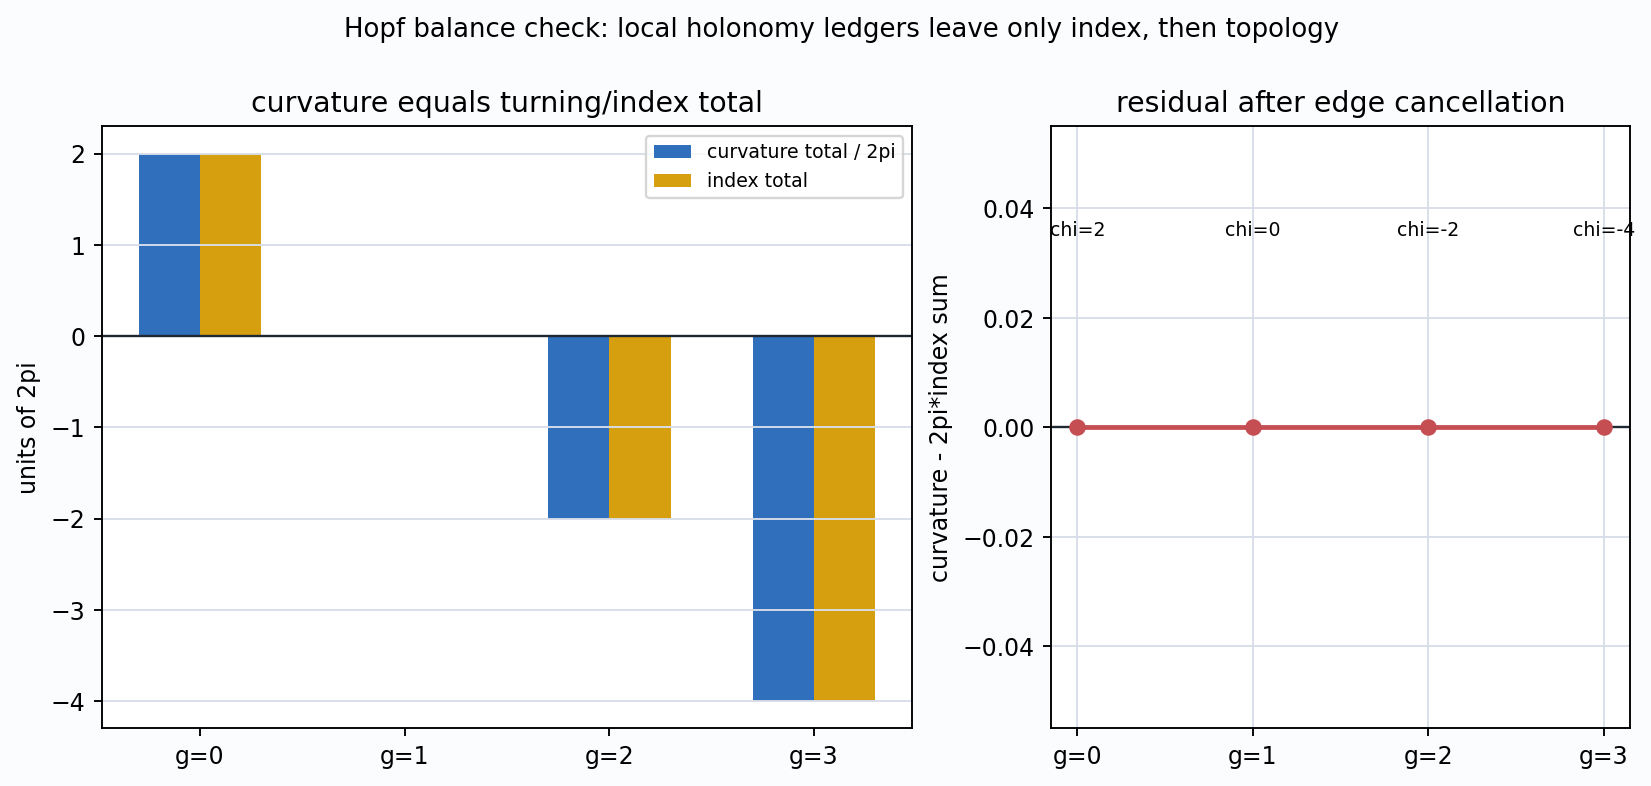

,genus,chi,indices,index_sum,total_curvature,two_pi_index_sum,residual
0,0,2,"[1, 1]",2,12.566371,12.566371,0.0
1,1,0,"[1, -1]",0,0.000000,0.000000,0.0
2,2,-2,"[-1, -1]",-2,-12.566371,-12.566371,0.0
3,3,-4,"[-1, -1, -1, -1]",-4,-25.132741,-25.132741,0.0


In [6]:
def balance_row(genus: int, indices: list[int]) -> dict[str, object]:
    chi = 2 - 2 * genus
    index_sum = sum(indices)
    total_curvature = 2 * math.pi * chi
    index_total = 2 * math.pi * index_sum
    return {
        "genus": genus,
        "chi": chi,
        "indices": indices,
        "index_sum": index_sum,
        "total_curvature": float(total_curvature),
        "two_pi_index_sum": float(index_total),
        "residual": float(total_curvature - index_total),
    }


balance_rows = [
    balance_row(0, [1, 1]),
    balance_row(1, [1, -1]),
    balance_row(2, [-1, -1]),
    balance_row(3, [-1, -1, -1, -1]),
]
residuals = np.array([row["residual"] for row in balance_rows], dtype=float)
balance_checks = {
    "residuals_all_zero": bool(np.allclose(residuals, 0.0, atol=1e-12)),
    "chi_values": [int(row["chi"]) for row in balance_rows],
    "index_sums_match_chi": bool(all(row["index_sum"] == row["chi"] for row in balance_rows)),
}

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.6, 4.6), facecolor=PALETTE["paper"], gridspec_kw={"width_ratios": [1.4, 1.0]})
genera = [row["genus"] for row in balance_rows]
curvature_units = [row["total_curvature"] / (2 * math.pi) for row in balance_rows]
index_units = [row["two_pi_index_sum"] / (2 * math.pi) for row in balance_rows]
ax0.bar(np.array(genera) - 0.15, curvature_units, width=0.3, color=PALETTE["blue"], label="curvature total / 2pi")
ax0.bar(np.array(genera) + 0.15, index_units, width=0.3, color=PALETTE["gold"], label="index total")
ax0.axhline(0, color=PALETTE["ink"], lw=1)
ax0.set_xticks(genera, [f"g={g}" for g in genera])
ax0.set_ylabel("units of 2pi")
ax0.set_title("curvature equals turning/index total")
ax0.legend(fontsize=8)
ax0.grid(True, axis="y", color="#d8dee9")

ax1.axhline(0, color=PALETTE["ink"], lw=1)
ax1.plot(genera, residuals, color=PALETTE["red"], marker="o", lw=2)
ax1.set_xticks(genera, [f"g={g}" for g in genera])
ax1.set_ylabel("curvature - 2pi*index sum")
ax1.set_title("residual after edge cancellation")
ax1.grid(True, color="#d8dee9")
for row in balance_rows:
    ax1.text(row["genus"], 0.035, f"chi={row['chi']}", ha="center", fontsize=8)

fig.suptitle("Hopf balance check: local holonomy ledgers leave only index, then topology", fontsize=11, y=1.02)
path_balance = save_and_register(fig, "curvature-turning-topology-balance.png", "Curvature, index, and topology balance", balance_checks)
assert balance_checks["residuals_all_zero"]
display(pd.DataFrame(balance_rows))


## Applied Lab: Break The Index Ledger On Purpose

The proof predicts that a closed surface ledger only balances when the total index matches the Euler characteristic. The small function below is meant to be edited: change the singularity indices and watch the residual report the mismatch. This is a useful guard against a common misconception: curvature is not being matched to the number of singularities, but to the **sum of their signed indices**.


In [7]:
def hopf_residual(genus: int, indices: list[int]) -> dict[str, object]:
    chi = 2 - 2 * genus
    residual = 2 * math.pi * (chi - sum(indices))
    return {
        "genus": genus,
        "chi": chi,
        "indices": indices,
        "index_sum": sum(indices),
        "residual": float(residual),
        "balances": bool(abs(residual) < 1e-12),
    }


lab_cases = {
    "sphere_two_sources": hopf_residual(0, [1, 1]),
    "sphere_missing_one_index": hopf_residual(0, [1]),
    "torus_source_sink": hopf_residual(1, [1, -1]),
    "genus_two_two_saddles": hopf_residual(2, [-1, -1]),
}
lab_checks = {
    "valid_cases_balance": bool(lab_cases["sphere_two_sources"]["balances"] and lab_cases["torus_source_sink"]["balances"] and lab_cases["genus_two_two_saddles"]["balances"]),
    "bad_case_detected": bool(not lab_cases["sphere_missing_one_index"]["balances"]),
}
lab_path = save_json(lab_cases, ARTIFACT_TOPIC, CHECK_SLUG, "balance-exploration.json", root=ARTIFACT_BASE)
assert all(lab_checks.values())
print(rel(lab_path))
display(pd.DataFrame(lab_cases).T)


artifacts/chapter-26/checks/balance-exploration.json


,genus,chi,indices,index_sum,residual,balances
sphere_two_sources,0,2,"[1, 1]",2,0.0,True
sphere_missing_one_index,0,2,[1],1,6.283185,False
torus_source_sink,1,0,"[1, -1]",0,0.0,True
genus_two_two_saddles,2,-2,"[-1, -1]",-2,0.0,True


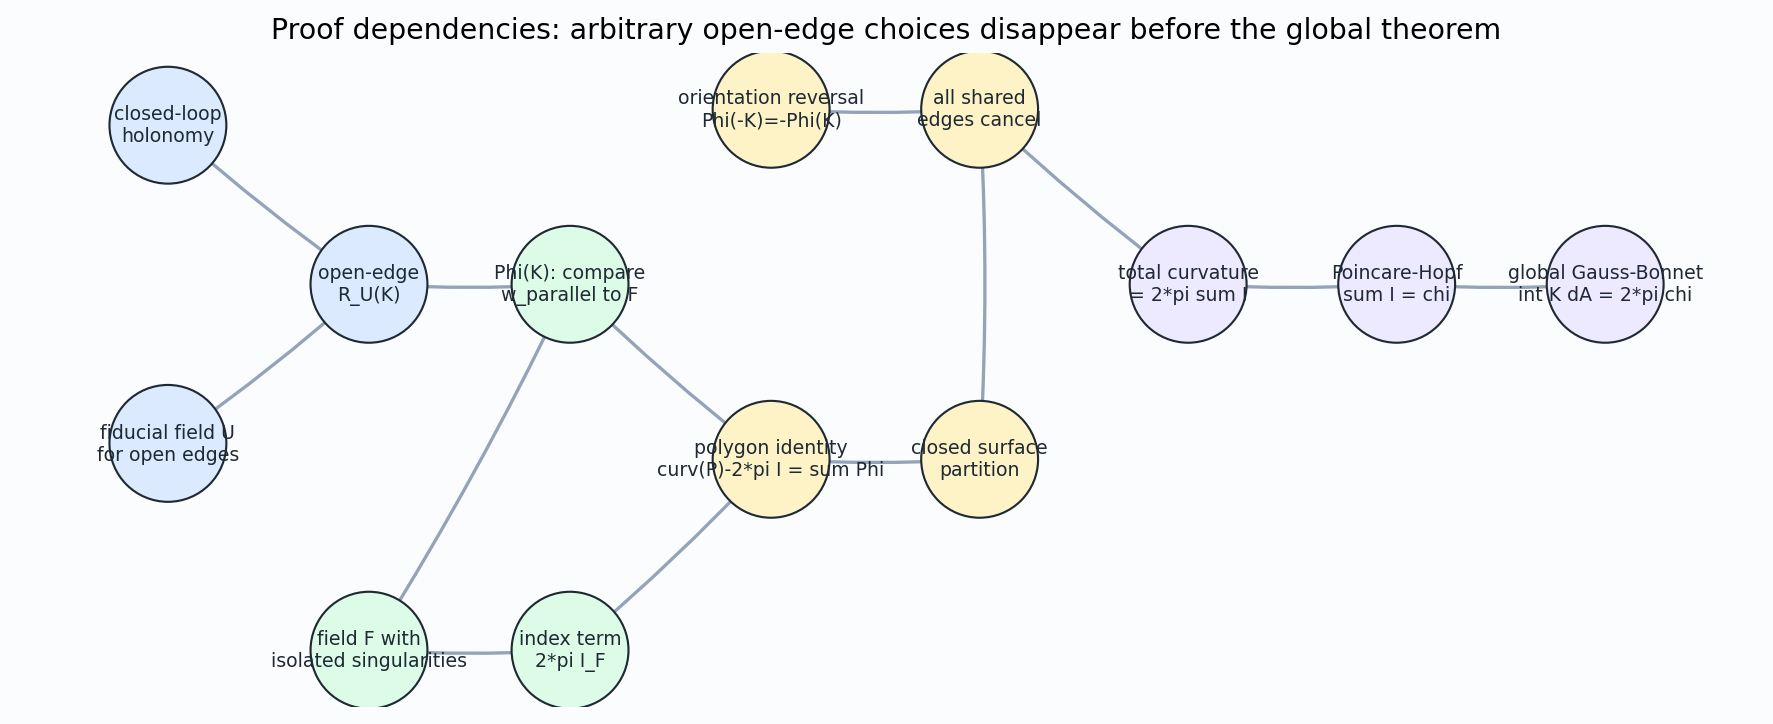

{
  "is_dag": true,
  "path_open_edge_to_ggb": true,
  "path_orientation_to_ggb": true,
  "node_count": 13,
  "edge_count": 13
}


In [8]:
G = nx.DiGraph()
node_labels = {
    "closed_holonomy": "closed-loop\nholonomy",
    "fiducial_U": "fiducial field U\nfor open edges",
    "open_edge_RU": "open-edge\nR_U(K)",
    "vector_field_F": "field F with\nisolated singularities",
    "index": "index term\n2*pi I_F",
    "Phi": "Phi(K): compare\nw_parallel to F",
    "polygon_identity": "polygon identity\ncurv(P)-2*pi I = sum Phi",
    "orientation": "orientation reversal\nPhi(-K)=-Phi(K)",
    "partition": "closed surface\npartition",
    "edge_cancel": "all shared\nedges cancel",
    "index_equality": "total curvature\n= 2*pi sum I",
    "poincare_hopf": "Poincare-Hopf\nsum I = chi",
    "ggb": "global Gauss-Bonnet\nint K dA = 2*pi chi",
}
G.add_nodes_from(node_labels)
G.add_edges_from([
    ("closed_holonomy", "open_edge_RU"),
    ("fiducial_U", "open_edge_RU"),
    ("open_edge_RU", "Phi"),
    ("vector_field_F", "Phi"),
    ("vector_field_F", "index"),
    ("index", "polygon_identity"),
    ("Phi", "polygon_identity"),
    ("polygon_identity", "partition"),
    ("orientation", "edge_cancel"),
    ("partition", "edge_cancel"),
    ("edge_cancel", "index_equality"),
    ("index_equality", "poincare_hopf"),
    ("poincare_hopf", "ggb"),
])
proof_checks = {
    "is_dag": bool(nx.is_directed_acyclic_graph(G)),
    "path_open_edge_to_ggb": bool(nx.has_path(G, "open_edge_RU", "ggb")),
    "path_orientation_to_ggb": bool(nx.has_path(G, "orientation", "ggb")),
    "node_count": int(G.number_of_nodes()),
    "edge_count": int(G.number_of_edges()),
}

pos = {
    "closed_holonomy": (0.0, 2.0),
    "fiducial_U": (0.0, 1.0),
    "open_edge_RU": (1.35, 1.5),
    "vector_field_F": (1.35, 0.35),
    "index": (2.7, 0.35),
    "Phi": (2.7, 1.5),
    "polygon_identity": (4.05, 0.95),
    "orientation": (4.05, 2.05),
    "partition": (5.45, 0.95),
    "edge_cancel": (5.45, 2.05),
    "index_equality": (6.85, 1.5),
    "poincare_hopf": (8.25, 1.5),
    "ggb": (9.65, 1.5),
}

fig, ax = plt.subplots(figsize=(13.2, 5.0), facecolor=PALETTE["paper"])
ax.axis("off")
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.4, edge_color="#94a3b8", connectionstyle="arc3,rad=0.03")
node_colors = ["#dbeafe" if node in {"closed_holonomy", "fiducial_U", "open_edge_RU"} else "#dcfce7" if node in {"vector_field_F", "index", "Phi"} else "#fef3c7" if node in {"polygon_identity", "orientation", "partition", "edge_cancel"} else "#ede9fe" for node in G.nodes]
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, edgecolors=PALETTE["ink"], linewidths=0.9, node_size=2450)
nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax, font_size=8, font_color=PALETTE["ink"])
ax.set_title("Proof dependencies: arbitrary open-edge choices disappear before the global theorem", fontsize=12)

path_graph = save_and_register(fig, "holonomy-proof-dependency-graph.png", "Holonomy proof dependency graph", proof_checks, width=900)
assert proof_checks["is_dag"] and proof_checks["path_open_edge_to_ggb"] and proof_checks["path_orientation_to_ggb"]
print(json.dumps(proof_checks, indent=2))


## Common Failure Modes

A sign error usually enters the proof in one of three places. First, reversing an edge must reverse the signed angle change; otherwise cancellation fails. Second, index is signed. A source and a sink are not interchangeable with a saddle when the total index is being compared with topology. Third, the theorem is for a closed surface in this form. If the partition has an exterior boundary, the edge ledger does not sum to zero; a boundary term must be kept.

The final dependency graph is meant to make those dependencies auditable. The open-edge construction feeds the `Phi` term, the vector field feeds both `Phi` and the index term, and orientation reversal feeds cancellation. Global Gauss-Bonnet only appears after all three threads meet.


## Takeaways

The fourth proof of global Gauss-Bonnet is intrinsic because it never needs a normal map or an embedding of the surface in Euclidean space. It uses only parallel transport, angle comparison in tangent planes, vector-field index, and a closed-surface partition.

The arbitrary fiducial field `U` is not a new geometric invariant. It is a temporary measuring stick that lets open edges be discussed. After subtracting the vector-field angle change, the surviving edge term `Phi(K)` has the sign behavior needed for cancellation. The closed surface condition then removes every boundary term, leaving total curvature equal to `2*pi` times total index. Poincare-Hopf turns that index sum into Euler characteristic.


In [9]:
chapter_check_payload = {
    "chapter_label": source_span["label"],
    "title": source_span["title"],
    "source_span": source_span,
    "storyboard_path": rel(storyboard_path),
    "visual_artifacts": visual_records,
    "open_curve_checks": open_curve_checks,
    "boundary_cancellation_checks": boundary_checks,
    "mesh_checks": mesh_checks,
    "mesh_summaries": mesh_summaries,
    "balance_checks": balance_checks,
    "balance_rows": balance_rows,
    "lab_checks": lab_checks,
    "lab_cases_path": rel(lab_path),
    "proof_graph_checks": proof_checks,
}

artifact_paths = [BOOK_ROOT / record["relative_path"] for record in visual_records]
artifact_assertions = {
    "visual_count_at_least_five": bool(len(visual_records) >= 5),
    "all_visual_paths_exist": bool(all(path.exists() for path in artifact_paths)),
    "all_visual_files_nonzero": bool(all(path.stat().st_size > 200 for path in artifact_paths)),
    "all_visuals_nonblank": bool(all(record["metrics"]["pixel_std"] > 1.0 for record in visual_records)),
    "concept_named_filenames": bool(all("-" in record["filename"] and record["filename"].endswith(".png") for record in visual_records)),
}

final_sanity = {
    "chapter_label": source_span["label"],
    "source_span": {"printed_pages": source_span["printed_pages"], "pdf_pages": source_span["pdf_pages"]},
    "storyboard": rel(storyboard_path),
    "check_artifact": "artifacts/chapter-26/checks/boundary-cancellation-gauss-bonnet.json",
    "visual_artifacts": [record["relative_path"] for record in visual_records],
    "assertions": {
        **artifact_assertions,
        "source_span_matches_assignment": bool(source_span["printed_pages"] == "257-260" and source_span["pdf_pages"] == "286-289"),
        "open_curve_U_dependence_detected": open_curve_checks["R_U_depends_on_U"],
        "transport_initial_vector_shift_invariant": open_curve_checks["constant_initial_vector_shift_invariant"],
        "oriented_edge_pair_cancels": boundary_checks["oriented_pair_cancels"],
        "sphere_chi_is_two": mesh_checks["sphere_chi_is_two"],
        "torus_chi_is_zero": mesh_checks["torus_chi_is_zero"],
        "closed_mesh_edges_have_two_faces": mesh_checks["closed_edges_have_two_faces"],
        "balance_residuals_zero": balance_checks["residuals_all_zero"],
        "lab_bad_case_detected": lab_checks["bad_case_detected"],
        "proof_graph_is_dag": proof_checks["is_dag"],
        "proof_graph_reaches_ggb": proof_checks["path_open_edge_to_ggb"] and proof_checks["path_orientation_to_ggb"],
    },
}

check_path = save_json(chapter_check_payload, ARTIFACT_TOPIC, CHECK_SLUG, "boundary-cancellation-gauss-bonnet.json", root=ARTIFACT_BASE)
final_path = save_json(final_sanity, ARTIFACT_TOPIC, CHECK_SLUG, "final-sanity.json", root=ARTIFACT_BASE)

assert all(final_sanity["assertions"].values()), {k: v for k, v in final_sanity["assertions"].items() if not v}
assert check_path.exists() and check_path.stat().st_size > 200
assert final_path.exists() and final_path.stat().st_size > 200

print(rel(check_path))
print(rel(final_path))
print(json.dumps(final_sanity["assertions"], indent=2, sort_keys=True))


artifacts/chapter-26/checks/boundary-cancellation-gauss-bonnet.json
artifacts/chapter-26/checks/final-sanity.json
{
  "all_visual_files_nonzero": true,
  "all_visual_paths_exist": true,
  "all_visuals_nonblank": true,
  "balance_residuals_zero": true,
  "closed_mesh_edges_have_two_faces": true,
  "concept_named_filenames": true,
  "lab_bad_case_detected": true,
  "open_curve_U_dependence_detected": true,
  "oriented_edge_pair_cancels": true,
  "proof_graph_is_dag": true,
  "proof_graph_reaches_ggb": true,
  "source_span_matches_assignment": true,
  "sphere_chi_is_two": true,
  "torus_chi_is_zero": true,
  "transport_initial_vector_shift_invariant": true,
  "visual_count_at_least_five": true
}
